# Sprint 3 : Optimisation du modèle retenu
### Projet : Prédiction du risque de diabète - BRFSS 2015
---
**Formation** : FISE A4 Data & IA - CESI Bordeaux  
**Dataset** : `diabetes_012_health_indicators_BRFSS2015.csv`  
**Livrable** : Sprint 3 : Optimisation, enrichissement et évaluation finale du modèle


## Sommaire

1. Contexte
2. Objectifs
3. Contraintes
4. Imports et configuration
5. Chargement des datasets
6. Choix du framework d'optimisation
7. Gestion du déséquilibre des classes
8. Espace de recherche et fonctions utilitaires
9. Optimisation du Modèle B
   - 9.1 Recherche automatique des hyperparamètres
   - 9.2 Entraînement du modèle B optimisé
   - 9.3 Évaluation sur la validation
10. Optimisation du Modèle C
   - 10.1 Recherche automatique des hyperparamètres
   - 10.2 Entraînement du modèle C optimisé
   - 10.3 Évaluation sur la validation
11. Comparaison des modèles optimisés
12. Analyse du seuil de décision
13. Évaluation finale sur le jeu de test
14. IA explicable (SHAP et LIME)
15. Empreinte carbone
16. Conclusion
17. Bibliographie

## 1. Contexte

&nbsp;&nbsp;&nbsp;&nbsp;Aux États-Unis, le diabète est l'une des maladies chroniques les plus répandues. En 2018, les CDC (les Centres pour le contrôle et la prévention des maladies) estimaient à 34,2 millions le nombre d'Américains diabétiques, et à 88 millions ceux en état de prédiabète, dont une grande majorité ignorait leur situation.

Cette maladie cause un dérèglement du sucre sanguin, ce qui, sur le long terme, peut engendrer des complications graves : maladies cardiovasculaires, insuffisance rénale, amputations, perte de la vue. Son coût économique est estimé à près de 300 milliards de dollars par an.

Le dataset utilisé provient du *Behavioral Risk Factor Surveillance System (BRFSS)*, une enquête téléphonique annuelle menée par les CDC auprès de plus de 400 000 Américains. Notre version (2015) contient 253 680 réponses et 22 variables relatives aux comportements de santé, antécédents médicaux et conditions socio-économiques des participants.

&nbsp;&nbsp;&nbsp;&nbsp;Le **livrable 3** constitue la partie "Optimisation et évaluation finale" du projet.  
Dans le livrable 2, nous avons construit et comparé trois architectures de réseaux de neurones de complexité croissante. Le **Modèle B** (2 couches cachées, architecture de 16 neurones puis 8 neurones) a été retenu comme point de départ pour ce livrable. Non pas parce qu'il obtient les meilleurs résultats bruts, mais parce qu'il représente le meilleur compromis entre capacité d'apprentissage et stabilité, et parce que ses résultats limités s'expliquent par des hyperparamètres génériques qui ne lui sont pas adaptés.  
C'est exactement le cas d'usage pour lequel la recherche automatique d'hyperparamètres est faite.  

L'objectif de ce livrable est de l'enrichir et de l'optimiser pour améliorer ses performances, en particulier sur le recall, qui est notre métrique médicale prioritaire.

L'échéance de ce livrable est fixée au 2 juin 2026 à 8h.

## 2. Objectifs

L'objectif de ce livrable est d'améliorer les performances du Modèle B issu du livrable 2.

D'abord, il s'agit d'explorer plusieurs axes d'optimisation : recherche automatique des hyperparamètres, meilleure gestion du déséquilibre des classes, et analyse du seuil de décision. L'idée est de comprendre ce qui freine le modèle et d'agir dessus de manière méthodique.

Ensuite, il s'agit d'évaluer le modèle enrichi sur le jeu de test et de le comparer au Modèle B du livrable 2 pour mesurer concrètement les gains obtenus.

À la fin de ce livrable, on devra être capables de dire si les optimisations apportées améliorent significativement les performances médicales du modèle, et dans quelle mesure il se rapproche d'un niveau acceptable pour une aide à la décision clinique.

## 3. Contraintes

Les contraintes de ce livrable sont les mêmes que celles du livrable 2, auxquelles s'ajoutent de nouvelles exigences liées à la finalisation du projet :

- Elles sont **médicales**. Si le modèle ne détecte pas un diabète chez un patient (un faux négatif), c'est bien plus grave que de signaler un diabète chez un patient qui n'en a pas. Une consultation supplémentaire "pour rien" est moins grave qu'un patient qui ne sait pas qu'il est diabétique. Maximiser le recall reste donc notre priorité absolue.

- Elles sont **éthiques**. Le modèle est amené à être utilisé par des médecins. Des vies humaines sont en jeu et ce dernier a un impact direct sur l'avenir des patients.

- Le modèle doit trouver le juste milieu entre performance et explicabilité. Puisque des médecins sont amenés à l'utiliser, ils doivent pouvoir en interpréter les résultats. Si le modèle est trop complexe, il n'est pas ou peu explicable et donc pas utilisable dans la pratique.

- Le modèle doit être capable de **généraliser**, c'est-à-dire qu'il doit éviter le **surapprentissage** pour fonctionner correctement sur de nouvelles données qu'il n'a jamais vues.  
Un modèle en surapprentissage mémorise les données d'entraînement au lieu d'en apprendre les patterns généraux, il performe très bien à l'entraînement mais devient inefficace face à de nouvelles données.

- Le jeu de données présente un **déséquilibre des classes** important (86% de non-diabétiques contre 14% de diabétiques). Ce déséquilibre a été partiellement traité dans le livrable 1 via SMOTE sur le jeu d'entraînement, mais les jeux de validation et de test conservent la distribution réelle.  
L'accuracy seule ne suffit donc pas comme métrique d'évaluation.

- Le modèle déployé en production engage la responsabilité du praticien et doit répondre aux exigences de l'**AI Act européen (Annexe III point 5)**, qui impose des standards de fiabilité, de transparence et de contrôle humain pour les systèmes à haut risque comme les outils d'aide au diagnostic.

## 4. Imports et configuration


In [1]:
# Suppression des avertissements non critiques
import warnings
warnings.filterwarnings('ignore')

# Librairies de base
import numpy as np
import pandas as pd
import time
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=tout, 1=info, 2=warning, 3=error seulement

DATA_PATH = 'data/processed/'

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Recall
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Recherche d'hyperparamètres
import keras_tuner as kt

# IA explicable et empreinte carbone
import shap
import lime
import lime.lime_tabular
from codecarbon import EmissionsTracker

# Métriques d'évaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Configuration graphique
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

# Graine aléatoire pour la reproductibilité des résultats
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('TensorFlow version :', tf.__version__)
print('Imports OK')

TensorFlow version : 2.21.0
Imports OK


## 5. Chargement des datasets


In [2]:
# Features
X_train = pd.read_csv(os.path.join(DATA_PATH, 'X_train.csv'))
X_val   = pd.read_csv(os.path.join(DATA_PATH, 'X_val.csv'))
X_test  = pd.read_csv(os.path.join(DATA_PATH, 'X_test.csv'))

# Labels
y_train = pd.read_csv(os.path.join(DATA_PATH, 'y_train.csv'))
y_val   = pd.read_csv(os.path.join(DATA_PATH, 'y_val.csv'))
y_test  = pd.read_csv(os.path.join(DATA_PATH, 'y_test.csv'))

# Aperçu des dimensions
print('X_train :', X_train.shape)
print('X_val   :', X_val.shape)
print('X_test  :', X_test.shape)
print('y_train :', y_train.shape)
print('y_val   :', y_val.shape)
print('y_test  :', y_test.shape)

X_train : (305668, 18)
X_val   : (38052, 18)
X_test  : (38052, 18)
y_train : (305668, 1)
y_val   : (38052, 1)
y_test  : (38052, 1)


## 6. Choix du framework d'optimisation

### Pourquoi chercher des hyperparamètres automatiquement ?

Dans le livrable 2, tous les modèles partageaient les mêmes hyperparamètres. C'était un choix délibéré pour que la comparaison soit honnête. Mais ce que le livrable 2 a montré, c'est que le Modèle B ne performe pas mal à cause de son architecture, il performe mal parce que ses hyperparamètres (learning rate, dropout, taille des couches, régularisation L2) ne lui sont pas adaptés.

Chercher manuellement la bonne combinaison serait long, pas rigoureux, et non reproductible. On utilise donc un framework de **recherche automatique d'hyperparamètres** qui va tester de nombreuses combinaisons de manière systématique et retenir celle qui donne les meilleurs résultats sur la validation.

### Comparaison des frameworks

Nous allons analyser deux options : **Keras Tuner** et **Optuna**.

- **Optuna** est un framework de recherche d'hyperparamètres agnostique au framework de deep learning. Il utilise par défaut une optimisation bayésienne via l'algorithme TPE (Tree-structured Parzen Estimator), ce qui le rend efficace pour explorer des espaces de recherche complexes.  
Il est particulièrement adapté quand on veut optimiser des pipelines hétérogènes (par exemple, un prétraitement + un modèle sklearn + un modèle Keras dans la même recherche).  
Sa flexibilité est grande mais elle demande plus de configuration manuelle. Nous devons définir nous-même la fonction objective, les essais, et les règles d'arrêt.

- **Keras Tuner** est le framework d'optimisation d'hyperparamètres pour Keras. Il s'intègre directement avec l'API Keras sans aucune configuration supplémentaire. On définit les hyperparamètres directement dans la fonction de construction du modèle avec `hp.Int`, `hp.Float`, `hp.Choice`, et Keras Tuner s'occupe du reste.  
Il propose plusieurs stratégies de recherche comme RandomSearch, Hyperband, BayesianOptimization et gère automatiquement l'EarlyStopping, la sauvegarde des meilleurs poids et les logs.

### Pourquoi on choisit Keras Tuner

Depuis le livrable 2, on utilise TensorFlow / Keras pour construire, entraîner et évaluer nos réseaux de neurones. Keras Tuner est conçu pour fonctionner directement avec cette librairie, sans configuration supplémentaire, ce qui évite d'introduire une nouvelle dépendance pour rien.

Optuna serait pertinent si on voulait optimiser un pipeline plus complexe ou comparer plusieurs frameworks de deep learning entre eux. Ce n'est pas notre cas. Ici on optimise un seul modèle Keras avec des hyperparamètres bien identifiés.  
L'utiliser ici ajouterait de la complexité sans apporter de bénéfice.

Enfin, Keras Tuner propose **Hyperband**, une stratégie bien adaptée à notre situation. On a beaucoup de combinaisons à tester et un budget de calcul limité. Hyperband résout ce problème en allouant plus de ressources aux combinaisons prometteuses et en arrêtant tôt celles qui ne donnent rien, ce qui le rend bien plus efficace qu'une recherche aléatoire classique.

C'est pour ces raisons qu'on retient **Keras Tuner avec la stratégie Hyperband**.

## 7. Gestion du déséquilibre des classes

### Rappel du déséquilibre

Comme établi dans le livrable 1, le dataset présente un déséquilibre important entre les deux classes. Le jeu d'entraînement contient environ 86% de non-diabétiques et 14% de diabétiques. Sans traitement, le modèle aurait tendance à privilégier la classe majoritaire et à ignorer les diabétiques, ce qui va directement à l'encontre des contraintes médicales du projet.

Dans le livrable 1, ce déséquilibre a été traité sur le jeu d'entraînement via **SMOTE** (Synthetic Minority Oversampling Technique). On rappelle ici son fonctionnement et on le compare à une alternative pour justifier pourquoi on le conserve dans ce livrable.

### SMOTE vs Class Weight

- **SMOTE** génère de nouveaux exemples synthétiques de la classe minoritaire en interpolant entre des exemples existants. Concrètement, pour chaque exemple diabétique, SMOTE sélectionne ses voisins les plus proches dans l'espace des features et crée de nouveaux points entre eux.  
Le jeu d'entraînement est ainsi rééquilibré sans dupliquer les mêmes exemples, ce qui force le modèle à apprendre des patterns plus variés sur la classe minoritaire. 

- **Class Weight** est une alternative plus simple qui ne modifie pas les données. On attribue un poids plus élevé à la classe minoritaire dans la fonction de loss. Une erreur sur un diabétique coûte proportionnellement plus cher au modèle qu'une erreur sur un non-diabétique.  
Le modèle est ainsi incité à mieux classer les diabétiques sans qu'on touche au dataset.

Les deux approches ont leurs avantages :  

Class Weight est plus rapide à mettre en place et ne crée pas de données synthétiques, ce qui peut être un avantage dans des contextes où la génération de données médicales est un soucis éthique (Cela depend du contexte, ce qui n'est pas notre cas, les données etant deja anonymisé).   
En revanche, SMOTE enrichit réellement le jeu d'entraînement avec de la diversité sur la classe minoritaire, ce qui aide le modèle à mieux généraliser sur des cas limites qu'il n'aurait pas vus autrement.

Dans notre cas, on conserve le SMOTE car il a déjà été appliqué dans le livrable 1. Changer de méthode maintenant fausserait la comparaison avec le Modèle B du livrable 2.

Distribution des classes (train après SMOTE) :
  Classe 0 : 152834 (50.0%)
  Classe 1 : 152834 (50.0%)


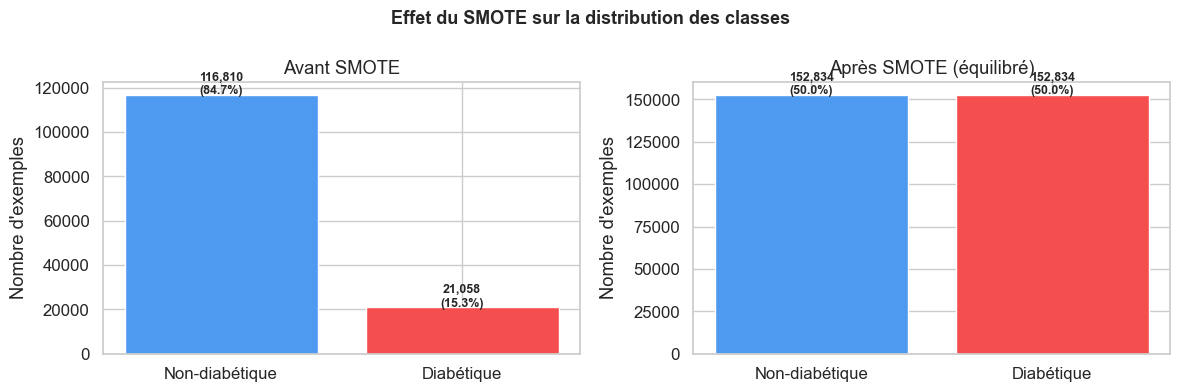

In [3]:
# Données avant SMOTE
counts_before = [116810, 21058]

# Données après SMOTE
unique, counts = np.unique(y_train, return_counts = True)
counts_after   = list(counts)

print('Distribution des classes (train après SMOTE) :')
for cls, cnt in zip(unique, counts):
    pct = cnt / len(y_train) * 100
    print(f'  Classe {int(cls)} : {cnt} ({pct:.1f}%)')

# Graphique
colors = ['#4e9af1', '#f44e4e']
labels = ['Non-diabétique', 'Diabétique']

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Avant SMOTE
bars = axes[0].bar(labels, counts_before, color = colors)
axes[0].set_title('Avant SMOTE')
axes[0].set_ylabel("Nombre d'exemples")
total = sum(counts_before)
for bar, val in zip(bars, counts_before):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{val:,}\n({val / total * 100:.1f}%)', ha = 'center', fontsize = 9, fontweight = 'bold')

# Après SMOTE
bars = axes[1].bar(labels, counts_after, color = colors)
axes[1].set_title('Après SMOTE (équilibré)')
axes[1].set_ylabel("Nombre d'exemples")
total = sum(counts_after)
for bar, val in zip(bars, counts_after):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{val:,}\n({val / total * 100:.1f}%)', ha = 'center', fontsize = 9, fontweight = 'bold')

plt.suptitle('Effet du SMOTE sur la distribution des classes', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

## 8. Espace de recherche et fonctions utilitaires

Avant de lancer la recherche, on doit définir deux choses : quels hyperparamètres on laisse Keras Tuner explorer, et quelques fonctions qu'on va réutiliser tout le long du livrable pour évaluer les modèles. Ça évite de réécrire le même code à chaque fois.

### Ce qu'on garde fixe et ce qu'on fait varier

On ne touche pas à la **profondeur** des modèles : le Modèle B garde ses deux couches cachées et le Modèle C ses trois couches, exactement comme au livrable 2. Ce qui change, c'est qu'au livrable 2 tout le reste était figé à la main, alors qu'ici on laisse le framework chercher la meilleure combinaison pour :

- le **nombre de neurones** de chaque couche cachée,
- le **taux de dropout**,
- la **régularisation L2**,
- le **learning rate**.

On ajoute aussi **deux paramètres supplémentaires** qu'on n'avait pas du tout testés dans le livrable 2 et qui servent à enrichir l'architecture :

- la **fonction d'activation** (`relu`, `tanh`, `elu`, `selu`) : jusqu'ici on utilisait toujours `relu` par défaut, mais rien ne dit que c'est la meilleure pour nos données.
- la **BatchNormalization** après chaque couche Dense : c'est une couche qui normalise les sorties entre les couches. Ça stabilise l'entraînement et ça aide souvent à réduire le surapprentissage, qui était justement notre gros problème dans le livrable 2. On la rend optionnelle (le tuner choisit de l'activer ou non).

Pour chaque paramètre numérique on définit une plage qui donne **environ une dizaine de valeurs possibles**, pour que la recherche ait de quoi explorer sans exploser le temps de calcul.

### Sur quoi on optimise ?

On dit à Keras Tuner de maximiser le **ROC-AUC sur la validation** (`val_auc`). On ne l'optimise pas directement sur le recall, et c'est volontaire : le recall dépend du seuil de décision, et le seuil on le réglera nous-mêmes juste après (section 12). Le ROC-AUC, lui, mesure la capacité du modèle à séparer les deux classes indépendamment du seuil. Donc on cherche d'abord le modèle qui sépare le mieux, et ensuite on règle le seuil pour attraper un maximum de diabétiques.

### Callbacks

On garde l'**EarlyStopping** pour couper l'entraînement quand la validation ne progresse plus (anti-surapprentissage), et on ajoute **ReduceLROnPlateau** qui réduit automatiquement le learning rate quand la loss stagne. Ça aide le modèle à affiner sa descente en fin d'entraînement au lieu de tourner en rond.

In [4]:
# Nombre de features en entrée
input_dim = X_train.shape[1]
print(f'Nombre de features en entrée : {input_dim}')

# y en tableau 1D (plus pratique pour les métriques sklearn)
y_train_arr = np.array(y_train).ravel()
y_val_arr   = np.array(y_val).ravel()
y_test_arr  = np.array(y_test).ravel()

Nombre de features en entrée : 18


In [5]:
# --- Fonction d'évaluation : calcule et affiche toutes les métriques ---
def evaluer(model, X, y, seuil = 0.5, nom = ''):
    y_prob = model.predict(X, verbose = 0).ravel()
    y_pred = (y_prob >= seuil).astype(int)

    acc  = accuracy_score(y,  y_pred)
    prec = precision_score(y, y_pred, zero_division = 0)
    rec  = recall_score(y,    y_pred, zero_division = 0)
    f1   = f1_score(y,        y_pred, zero_division = 0)
    auc  = roc_auc_score(y,   y_prob)

    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f'Résultats {nom} (seuil = {seuil})')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  TN = {tn}  FP = {fp}')
    print(f'  FN = {fn}  TP = {tp}')
    print(f'  {fn} diabétiques non détectés (faux négatifs)')

    return {'nom': nom, 'seuil': seuil, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'auc': auc,
            'fn': int(fn), 'fp': int(fp), 'y_prob': y_prob}


# --- Fonction d'analyse du seuil (reprise du livrable 2) ---
def analyse_seuil(y, y_prob, nom_modele, seuils = None):
    if seuils is None:
        seuils = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
    resultats = []
    for s in seuils:
        y_pred = (y_prob >= s).astype(int)
        rec  = recall_score(y,    y_pred, zero_division = 0)
        prec = precision_score(y, y_pred, zero_division = 0)
        f1   = f1_score(y,        y_pred, zero_division = 0)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
        resultats.append({'Seuil': s, 'Recall': round(rec, 4),
                          'Precision': round(prec, 4), 'F1-score': round(f1, 4),
                          'FN': fn, 'FP': fp})
    df = pd.DataFrame(resultats).set_index('Seuil')
    print(f'\nAnalyse du seuil : {nom_modele}')
    print(df.to_string())
    return df


# --- Choix du seuil : on garde le plus grand seuil qui respecte encore la cible de recall ---
def choisir_seuil(y, y_prob, recall_cible = 0.85):
    seuil_retenu = 0.5
    for s in np.round(np.arange(0.05, 0.96, 0.05), 2):
        rec = recall_score(y, (y_prob >= s).astype(int), zero_division = 0)
        if rec >= recall_cible:
            seuil_retenu = s
    return seuil_retenu


# --- Fonction pour tracer les courbes d'apprentissage ---
def tracer_courbes(history, nom = ''):
    fig, axes = plt.subplots(1, 2, figsize = (14, 4))
    axes[0].plot(history.history['loss'],     label = 'Train')
    axes[0].plot(history.history['val_loss'], label = 'Validation')
    axes[0].set_title('Loss');     axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history.history['auc'],     label = 'Train')
    axes[1].plot(history.history['val_auc'], label = 'Validation')
    axes[1].set_title('ROC-AUC');  axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.suptitle(f'Courbes d\'apprentissage : {nom}', fontsize = 13, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

print('Fonctions utilitaires définies.')

Fonctions utilitaires définies.


## 9. Optimisation du Modèle B

On part du Modèle B du livrable 2 (deux couches cachées) et on le confie à Keras Tuner. Le but c'est de trouver la combinaison d'hyperparamètres qui lui correspond vraiment, au lieu des paramètres génériques qu'on lui avait imposés.

### 9.1 Recherche automatique des hyperparamètres

On définit d'abord la fonction qui construit le modèle. Le nombre de couches reste fixe (deux couches cachées, comme au livrable 2). Au lieu de mettre des valeurs fixes pour le reste, on utilise `hp.Int`, `hp.Float`, `hp.Choice` et `hp.Boolean` : c'est comme ça qu'on dit à Keras Tuner quelles valeurs il a le droit de tester pour chaque hyperparamètre.

In [6]:
# Fonction de construction du Modèle B avec hyperparamètres variables
# La profondeur reste fixe : 2 couches cachées, comme au livrable 2
def construire_modele_B(hp):
    # Les deux nouveaux paramètres
    activation = hp.Choice('activation', ['relu', 'tanh', 'elu', 'selu'])
    batchnorm  = hp.Boolean('batchnorm')

    # Les hyperparamètres classiques
    units_1 = hp.Int('units_1', min_value = 8, max_value = 80, step = 8)   # neurones couche 1
    units_2 = hp.Int('units_2', min_value = 4, max_value = 40, step = 4)   # neurones couche 2
    dropout = hp.Float('dropout', min_value = 0.1, max_value = 0.5, step = 0.05)
    l2_reg  = hp.Choice('l2_reg', [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3])
    lr      = hp.Choice('learning_rate', [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3])

    model = Sequential(name = 'model_B_opt')
    model.add(Input(shape = (input_dim,)))

    # Couche cachée 1 : Dense -> (BatchNorm) -> Activation -> Dropout
    model.add(Dense(units_1, kernel_regularizer = l2(l2_reg)))
    if batchnorm:
        model.add(BatchNormalization())
    model.add(Activation(activation))
    model.add(Dropout(dropout))

    # Couche cachée 2
    model.add(Dense(units_2, kernel_regularizer = l2(l2_reg)))
    if batchnorm:
        model.add(BatchNormalization())
    model.add(Activation(activation))
    model.add(Dropout(dropout))

    # Sortie
    model.add(Dense(1, activation = 'sigmoid'))

    model.compile(
        optimizer = Adam(learning_rate = lr),
        loss = 'binary_crossentropy',
        metrics = ['accuracy', AUC(name = 'auc'), Recall(name = 'recall')]
    )
    return model

print('Fonction de construction du Modèle B définie.')

Fonction de construction du Modèle B définie.


In [7]:
# Recherche Hyperband sur le Modèle B
tuner_B = kt.Hyperband(
    construire_modele_B,
    objective = kt.Objective('val_auc', direction = 'max'),
    max_epochs = 15,
    factor = 3,
    hyperband_iterations = 1,
    directory = 'keras_tuner',
    project_name = 'modele_B',
    overwrite = True,
    seed = RANDOM_STATE
)

# EarlyStopping pendant la recherche pour ne pas perdre de temps sur les mauvaises combinaisons
stop_recherche = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

# Lancement de la recherche (peut être long selon la machine)
tuner_B.search(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 15,
    batch_size = 1024,
    callbacks = [stop_recherche],
    verbose = 1
)

# Récupération des meilleurs hyperparamètres
best_hp_B = tuner_B.get_best_hyperparameters(num_trials = 1)[0]

print('\nMeilleurs hyperparamètres trouvés pour le Modèle B :')
for p in ['units_1', 'units_2', 'activation', 'batchnorm', 'dropout', 'l2_reg', 'learning_rate']:
    print(f'  {p:14}: {best_hp_B.get(p)}')

Trial 30 Complete [00h 00m 17s]
val_auc: 0.7950786352157593

Best val_auc So Far: 0.7999966144561768
Total elapsed time: 00h 03m 37s

Meilleurs hyperparamètres trouvés pour le Modèle B :
  units_1       : 24
  units_2       : 8
  activation    : selu
  batchnorm     : True
  dropout       : 0.2
  l2_reg        : 0.005
  learning_rate : 0.002


### 9.2 Entraînement du modèle B optimisé

On reconstruit le modèle avec les meilleurs hyperparamètres trouvés, et on l'entraîne pour de vrai cette fois (plus d'epochs que pendant la recherche). On ajoute `ReduceLROnPlateau` en plus de l'`EarlyStopping`.

In [8]:
# Construction du modèle avec les meilleurs hyperparamètres
model_B_opt = tuner_B.hypermodel.build(best_hp_B)
model_B_opt.summary()

# Callbacks pour l'entraînement final
callbacks_B = [
    EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

history_B = model_B_opt.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 50,
    batch_size = 1024,
    callbacks = callbacks_B,
    verbose = 1
)

Model: "model_B_opt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 24)                  │             456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 793 (3.10 KB)

 Trainable params: 729 (2.85 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7257 - auc: 0.7968 - loss: 0.6147 - recall: 0.7496 - val_accuracy: 0.6913 - val_auc: 0.7968 - val_loss: 0.5866 - val_recall: 0.7716 - learning_rate: 0.0020
Epoch 2/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7397 - auc: 0.8128 - loss: 0.5321 - recall: 0.7752 - val_accuracy: 0.6950 - val_auc: 0.7974 - val_loss: 0.5578 - val_recall: 0.7691 - learning_rate: 0.0020
Epoch 3/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7413 - auc: 0.8146 - loss: 0.5255 - recall: 0.7796 - val_accuracy: 0.6950 - val_auc: 0.7958 - val_loss: 0.5479 - val_recall: 0.7633 - learning_rate: 0.0020
Epoch 4/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7415 - auc: 0.8149 - loss: 0.5247 - recall: 0.7825 - val_accuracy: 0.7049 - val_auc: 0.7998 - val_loss: 0.5358 - val_recall: 0.7575 - learning_rate: 0.0020
Epoch 5/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7422 - auc: 0.8151 - loss: 0.5242 - recall: 0.

### 9.3 Évaluation sur la validation

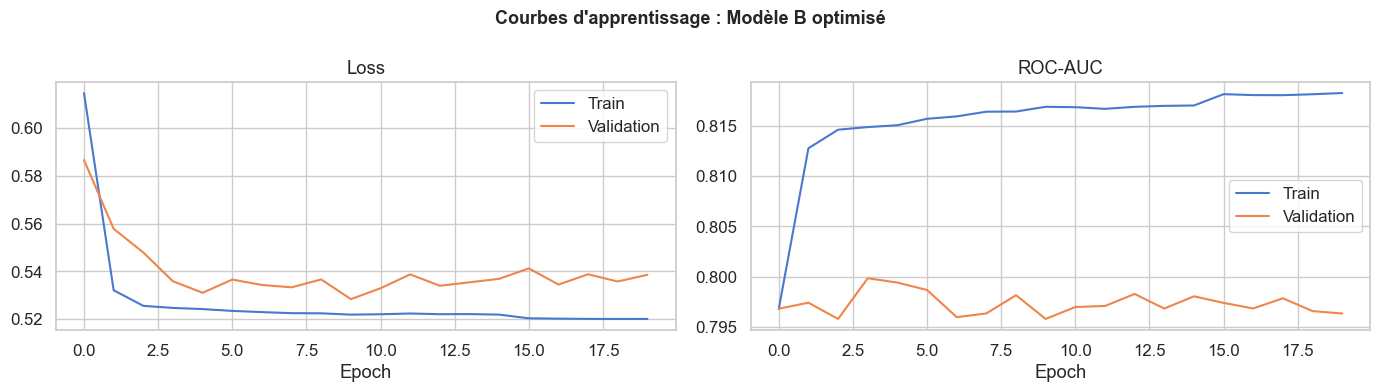

Résultats Modèle B optimisé : Validation (seuil = 0.5)
  Accuracy  : 0.7081
  Precision : 0.2892
  Recall    : 0.7512
  F1-score  : 0.4176
  ROC-AUC   : 0.7958
  TN = 22961  FP = 9789
  FN = 1319  TP = 3983
  1319 diabétiques non détectés (faux négatifs)


In [9]:
# Courbes d'apprentissage
tracer_courbes(history_B, nom = 'Modèle B optimisé')

# Évaluation au seuil par défaut (0.5)
res_B_opt = evaluer(model_B_opt, X_val, y_val_arr, seuil = 0.5, nom = 'Modèle B optimisé : Validation')

#### Analyse des résultats du Modèle B optimisé

> **À compléter après exécution.** Compare les chiffres obtenus ci-dessus avec le Modèle B du livrable 2 (au seuil 0.5 : ROC-AUC = 0.7933, recall = 0.7654, 1244 faux négatifs).

Points à regarder dans l'analyse :

- **ROC-AUC** : est-ce qu'il passe au-dessus de 0.7933 ? C'est le signe que la recherche d'hyperparamètres a amélioré la capacité de séparation du modèle.
- **Faux négatifs et recall** : c'est notre critère médical prioritaire. Est-ce qu'on descend en dessous des 1244 faux négatifs du livrable 2 ? (Attention, ici on est encore au seuil 0.5, le vrai gain viendra surtout du réglage du seuil en section 12.)
- **Courbes d'apprentissage** : est-ce que la loss de validation est plus stable qu'avant ? Si la BatchNormalization a été retenue par le tuner, on devrait voir moins d'oscillations et un surapprentissage mieux contrôlé qu'au livrable 2.
- **Les hyperparamètres retenus** : commenter ce que le tuner a choisi (activation, batchnorm activée ou non, taille des couches) et si ça a du sens.

## 10. Optimisation du Modèle C

Dans la conclusion du livrable 2, on avait dit que l'écart entre le Modèle B et le Modèle C était faible, et qu'une fois le B optimisé on ferait aussi une recherche d'hyperparamètres propre au C pour vérifier s'il devient finalement meilleur. C'est ce qu'on fait ici.

Le Modèle C a trois couches cachées au lieu de deux. Au livrable 2 il était le plus instable et le pire sur les faux négatifs, mais c'était avec des hyperparamètres qui ne lui étaient pas adaptés. On lui donne donc sa chance avec sa propre recherche, en gardant ses trois couches.

### 10.1 Recherche automatique des hyperparamètres

Même logique que pour le Modèle B, mais avec une troisième couche cachée (`units_3`). La profondeur reste fixe : trois couches, comme au livrable 2.

In [10]:
# Fonction de construction du Modèle C
# La profondeur reste fixe : 3 couches cachées, comme au livrable 2
def construire_modele_C(hp):
    activation = hp.Choice('activation', ['relu', 'tanh', 'elu', 'selu'])
    batchnorm  = hp.Boolean('batchnorm')

    units_1 = hp.Int('units_1', min_value = 16, max_value = 96, step = 8)
    units_2 = hp.Int('units_2', min_value = 8,  max_value = 64, step = 8)
    units_3 = hp.Int('units_3', min_value = 4,  max_value = 40, step = 4)
    dropout = hp.Float('dropout', min_value = 0.1, max_value = 0.5, step = 0.05)
    l2_reg  = hp.Choice('l2_reg', [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3])
    lr      = hp.Choice('learning_rate', [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3])

    model = Sequential(name = 'model_C_opt')
    model.add(Input(shape = (input_dim,)))

    for units in [units_1, units_2, units_3]:
        model.add(Dense(units, kernel_regularizer = l2(l2_reg)))
        if batchnorm:
            model.add(BatchNormalization())
        model.add(Activation(activation))
        model.add(Dropout(dropout))

    model.add(Dense(1, activation = 'sigmoid'))

    model.compile(
        optimizer = Adam(learning_rate = lr),
        loss = 'binary_crossentropy',
        metrics = ['accuracy', AUC(name = 'auc'), Recall(name = 'recall')]
    )
    return model

print('Fonction de construction du Modèle C définie.')

Fonction de construction du Modèle C définie.


In [ ]:
# Recherche Hyperband sur le Modèle C
tuner_C = kt.Hyperband(
    construire_modele_C,
    objective = kt.Objective('val_auc', direction = 'max'),
    max_epochs = 15,
    factor = 3,
    hyperband_iterations = 1,
    directory = 'keras_tuner',
    project_name = 'modele_C',
    overwrite = True,
    seed = RANDOM_STATE
)

stop_recherche_C = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

tuner_C.search(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 15,
    batch_size = 1024,
    callbacks = [stop_recherche_C],
    verbose = 1
)

best_hp_C = tuner_C.get_best_hyperparameters(num_trials = 1)[0]

print('\nMeilleurs hyperparamètres trouvés pour le Modèle C :')
for p in ['units_1', 'units_2', 'units_3', 'activation', 'batchnorm', 'dropout', 'l2_reg', 'learning_rate']:
    print(f'  {p:14}: {best_hp_C.get(p)}')

Trial 9 Complete [00h 00m 05s]
val_auc: 0.7976365089416504

Best val_auc So Far: 0.8005969524383545
Total elapsed time: 00h 00m 42s

Search: Running Trial #10

Value             |Best Value So Far |Hyperparameter
relu              |elu               |activation
True              |False             |batchnorm
88                |48                |units_1
16                |24                |units_2
32                |36                |units_3
0.5               |0.25              |dropout
0.0005            |0.0005            |l2_reg
0.0001            |0.0001            |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2


### 10.2 Entraînement du modèle C optimisé

In [ ]:
model_C_opt = tuner_C.hypermodel.build(best_hp_C)
model_C_opt.summary()

callbacks_C = [
    EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

history_C = model_C_opt.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 50,
    batch_size = 1024,
    callbacks = callbacks_C,
    verbose = 1
)

### 10.3 Évaluation sur la validation

In [ ]:
tracer_courbes(history_C, nom = 'Modèle C optimisé')

res_C_opt = evaluer(model_C_opt, X_val, y_val_arr, seuil = 0.5, nom = 'Modèle C optimisé : Validation')

#### Analyse des résultats du Modèle C optimisé

> **À compléter après exécution.** Compare avec le Modèle C du livrable 2 (au seuil 0.5 : ROC-AUC = 0.7935, recall = 0.7405, 1376 faux négatifs) et surtout avec le Modèle B optimisé juste au-dessus.

Points à regarder :

- Est-ce que l'optimisation a permis au Modèle C de rattraper son retard du livrable 2 ? Au livrable 2 il était le pire sur les faux négatifs, mais c'était à cause d'hyperparamètres inadaptés à sa profondeur.
- Est-ce que la troisième couche apporte vraiment quelque chose une fois bien réglée, ou est-ce qu'on reste sur le même plafond de performance ?
- Est-ce que le surapprentissage est mieux contrôlé qu'au livrable 2 grâce à la BatchNormalization et au dropout optimisé ?
- Le modèle C a plus de paramètres que le B : est-ce que le léger gain (s'il y en a un) justifie la complexité en plus, sachant la contrainte d'explicabilité ?

## 11. Comparaison des modèles optimisés

On met côte à côte trois modèles, tous au seuil 0.5 pour que la comparaison soit honnête :
- le **Modèle B du livrable 2** (avant optimisation), comme point de référence,
- le **Modèle B optimisé**,
- le **Modèle C optimisé**.

On choisit ensuite lequel des deux modèles optimisés on garde pour la suite (analyse de seuil et évaluation finale).

In [ ]:
# Rappel des résultats du Modèle B du livrable 2 (seuil 0.5, sur la validation)
ref_B_livrable2 = {
    'nom': 'Modèle B (livrable 2)',
    'accuracy': 0.6937, 'precision': 0.2804, 'recall': 0.7654,
    'f1': 0.4105, 'auc': 0.7933, 'fn': 1244
}

comparaison = pd.DataFrame([
    {'Modèle': ref_B_livrable2['nom'],
     'Accuracy': round(ref_B_livrable2['accuracy'], 4),
     'Precision': round(ref_B_livrable2['precision'], 4),
     'Recall': round(ref_B_livrable2['recall'], 4),
     'F1-score': round(ref_B_livrable2['f1'], 4),
     'ROC-AUC': round(ref_B_livrable2['auc'], 4),
     'FN (diabétiques ratés)': ref_B_livrable2['fn']},

    {'Modèle': 'Modèle B optimisé',
     'Accuracy': round(res_B_opt['accuracy'], 4),
     'Precision': round(res_B_opt['precision'], 4),
     'Recall': round(res_B_opt['recall'], 4),
     'F1-score': round(res_B_opt['f1'], 4),
     'ROC-AUC': round(res_B_opt['auc'], 4),
     'FN (diabétiques ratés)': res_B_opt['fn']},

    {'Modèle': 'Modèle C optimisé',
     'Accuracy': round(res_C_opt['accuracy'], 4),
     'Precision': round(res_C_opt['precision'], 4),
     'Recall': round(res_C_opt['recall'], 4),
     'F1-score': round(res_C_opt['f1'], 4),
     'ROC-AUC': round(res_C_opt['auc'], 4),
     'FN (diabétiques ratés)': res_C_opt['fn']},
]).set_index('Modèle')

print('Comparaison des modèles (validation, seuil = 0.5)')
comparaison

In [ ]:
# Courbes ROC des deux modèles optimisés
fig, ax = plt.subplots(figsize = (8, 6))

for y_prob, auc_val, label, color in [
    (res_B_opt['y_prob'], res_B_opt['auc'], 'Modèle B optimisé', 'darkorange'),
    (res_C_opt['y_prob'], res_C_opt['auc'], 'Modèle C optimisé', 'seagreen'),
]:
    fpr, tpr, _ = roc_curve(y_val_arr, y_prob)
    ax.plot(fpr, tpr, linewidth = 2, color = color,
            label = f'{label} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth = 1, label = 'Aléatoire (AUC = 0.5)')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (Recall)')
ax.set_title('Courbes ROC : Modèles B et C optimisés')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Choix du modèle retenu : on prend celui qui a le meilleur ROC-AUC sur la validation
# (le ROC-AUC mesure la capacité de séparation, indépendamment du seuil qu'on règlera après)
if res_B_opt['auc'] >= res_C_opt['auc']:
    model_final = model_B_opt
    tuner_final = tuner_B
    best_hp_final = best_hp_B
    res_final = res_B_opt
    nom_final = 'Modèle B optimisé'
else:
    model_final = model_C_opt
    tuner_final = tuner_C
    best_hp_final = best_hp_C
    res_final = res_C_opt
    nom_final = 'Modèle C optimisé'

print(f'Modèle retenu pour la suite : {nom_final}')
print(f'  ROC-AUC (validation) : {res_final["auc"]:.4f}')

### 11.1 Analyse de la comparaison

> **À compléter après exécution.** S'appuyer sur le tableau et les courbes ROC ci-dessus.

Points à traiter :

- **Gain de l'optimisation** : de combien le Modèle B optimisé fait-il mieux que le Modèle B du livrable 2 ? C'est ça qui justifie tout le travail de ce livrable.
- **B optimisé vs C optimisé** : lequel sépare le mieux (ROC-AUC) ? Lequel rate le moins de diabétiques ? Sont-ils proches comme au livrable 2 ou est-ce que l'optimisation a creusé l'écart ?
- **Compromis complexité et explicabilité** : si le C ne fait pas nettement mieux que le B, on préfère le B parce qu'il est plus léger et plus simple à expliquer à un médecin (contrainte d'explicabilité et AI Act). Si le C fait clairement mieux sur les faux négatifs, alors on le garde, comme on l'avait prévu dans le livrable 2.
- Justifier clairement le modèle retenu (la cellule de code l'a choisi automatiquement sur le ROC-AUC, mais c'est à nous d'argumenter le choix par rapport au besoin médical).

## 12. Analyse du seuil de décision

Comme dans le livrable 2, le seuil de 0.5 n'est pas adapté à notre contexte médical. Un seuil plus bas classe plus de patients comme diabétiques, donc rate moins de vrais diabétiques (moins de faux négatifs), au prix de quelques fausses alertes en plus. Vu nos contraintes, c'est un compromis qu'on accepte : une consultation en trop est moins grave qu'un diabétique non détecté.

On refait donc l'analyse de seuil sur le modèle retenu, et on choisit un seuil qui garantit un **recall d'au moins 0.85** (on attrape au moins 85% des diabétiques), tout en gardant la meilleure précision possible parmi les seuils acceptables.

In [ ]:
# Tableau du seuil pour le modèle retenu
df_seuil_final = analyse_seuil(y_val_arr, res_final['y_prob'], nom_final,
                               seuils = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50])

# Choix automatique du seuil (recall cible >= 0.85)
seuil_optimal = choisir_seuil(y_val_arr, res_final['y_prob'], recall_cible = 0.85)
print(f'\nSeuil retenu : {seuil_optimal}')

In [ ]:
# Graphique : évolution des métriques selon le seuil
seuils_graph = np.round(np.arange(0.20, 0.61, 0.05), 2)
recs, precs, f1s = [], [], []
for s in seuils_graph:
    yp = (res_final['y_prob'] >= s).astype(int)
    recs.append(recall_score(y_val_arr, yp, zero_division = 0))
    precs.append(precision_score(y_val_arr, yp, zero_division = 0))
    f1s.append(f1_score(y_val_arr, yp, zero_division = 0))

fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(seuils_graph, recs,  marker = 'o', label = 'Recall')
ax.plot(seuils_graph, precs, marker = 'o', label = 'Precision')
ax.plot(seuils_graph, f1s,   marker = 'o', label = 'F1-score')
ax.axvline(x = seuil_optimal, color = 'red', linestyle = '--', label = f'Seuil retenu = {seuil_optimal}')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title(f'Évolution des métriques selon le seuil : {nom_final}')
ax.legend()
plt.tight_layout()
plt.show()

### 12.1 Analyse du seuil

> **À compléter après exécution.**

Points à traiter :

- Rappeler l'arbitrage : quand on baisse le seuil, le recall monte et les faux négatifs baissent, mais les faux positifs augmentent.
- Justifier le seuil retenu en le reliant à la contrainte médicale : combien de diabétiques en plus détecte-t-on par rapport au seuil 0.5 ? Combien de faux positifs ça coûte en échange ?
- Conclure que c'est le médecin qui garde la décision finale (le modèle est une aide), donc accepter quelques fausses alertes est raisonnable.

## 13. Évaluation finale sur le jeu de test

Jusqu'ici on a tout réglé sur la validation. Le jeu de test n'a jamais été utilisé, ni pour l'entraînement ni pour le choix du seuil. C'est lui qui donne la vraie mesure de performance sur des données totalement nouvelles, comme ce serait le cas en conditions réelles. On évalue le modèle retenu au seuil choisi à la section 12.

In [ ]:
# Évaluation finale sur le test, au seuil optimal
print(f'=== {nom_final} : Jeu de TEST (seuil = {seuil_optimal}) ===\n')
res_test = evaluer(model_final, X_test, y_test_arr, seuil = seuil_optimal,
                   nom = f'{nom_final} : Test')

# Matrice de confusion
y_pred_test = (res_test['y_prob'] >= seuil_optimal).astype(int)
cm = confusion_matrix(y_test_arr, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Non-diabétique', 'Diabétique'])
fig, ax = plt.subplots(figsize = (6, 6))
disp.plot(ax = ax, cmap = 'Blues', values_format = 'd', colorbar = False)
ax.set_title(f'Matrice de confusion : {nom_final} (test, seuil = {seuil_optimal})')
plt.tight_layout()
plt.show()

In [ ]:
# Temps d'inférence : combien de temps pour classer les patients du jeu de test ?
debut = time.time()
_ = model_final.predict(X_test, verbose = 0)
duree = time.time() - debut
print(f'Temps pour classer {len(X_test)} patients : {duree:.3f} s')
print(f'Soit environ {duree / len(X_test) * 1000:.4f} ms par patient')

### 13.1 Analyse finale

> **À compléter après exécution.**

Points à traiter :

- Les résultats sur le test sont-ils cohérents avec la validation ? Si oui, ça veut dire que le modèle généralise bien et qu'on n'a pas surajusté le seuil.
- Reprendre la matrice de confusion : combien de diabétiques détectés, combien ratés (les FN en bas à gauche, les plus critiques).
- Le temps d'inférence très faible par patient est un bon point pour une utilisation en cabinet médical (réponse quasi instantanée).

## 14. IA explicable (SHAP et LIME)

Un modèle utilisé par des médecins ne peut pas être une boîte noire. Le praticien doit pouvoir comprendre pourquoi le modèle prédit un risque de diabète pour un patient donné. C'est aussi une exigence de l'AI Act pour les systèmes à haut risque. On utilise deux méthodes d'explicabilité complémentaires.

- **SHAP** donne une vue **globale** : quelles variables comptent le plus dans les prédictions du modèle, sur l'ensemble des patients.
- **LIME** donne une vue **locale** : pour un patient précis, qu'est-ce qui a poussé le modèle vers "diabétique" ou "non-diabétique".

On reste sur des versions simples (petits échantillons) pour que ça tourne en un temps raisonnable. Le but ici est surtout de pouvoir présenter les deux et les comparer à la soutenance.

### 14.1 SHAP : importance globale des variables

In [ ]:
# On prend un petit échantillon de fond et un petit échantillon à expliquer (pour la vitesse)
X_fond        = X_train.sample(100, random_state = RANDOM_STATE)
X_a_expliquer = X_test.sample(100, random_state = RANDOM_STATE)

# Fonction de prédiction du modèle (probabilité de diabète)
def predire(x):
    return model_final.predict(x, verbose = 0).ravel()

# KernelExplainer (méthode générale, simple à mettre en place)
explainer_shap = shap.KernelExplainer(predire, X_fond)
shap_values = explainer_shap.shap_values(X_a_expliquer, nsamples = 100)

# Graphique d'importance globale
shap.summary_plot(shap_values, X_a_expliquer, feature_names = X_test.columns.tolist())

> **À compléter après exécution.** Commenter les 3-4 variables qui ressortent comme les plus importantes (par exemple BMI, GenHlth, Age...) et vérifier que ça a du sens médicalement. Si les variables importantes sont des facteurs de risque connus du diabète, c'est rassurant : le modèle ne décide pas au hasard.

### 14.2 LIME : explication locale pour un patient

In [ ]:
# Explainer LIME sur les données d'entraînement
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names = X_train.columns.tolist(),
    class_names = ['Non-diabétique', 'Diabétique'],
    mode = 'classification'
)

# LIME a besoin des probabilités des deux classes
def predire_proba(x):
    p = model_final.predict(x, verbose = 0).ravel()
    return np.column_stack([1 - p, p])

# On explique un patient du jeu de test
i = 0
explication = explainer_lime.explain_instance(X_test.values[i], predire_proba, num_features = 10)

print(f'Patient {i} : probabilité de diabète prédite = {predire(X_test.values[i:i+1])[0]:.3f}')
explication.as_pyplot_figure()
plt.tight_layout()
plt.show()

> **À compléter après exécution.** Décrire pour ce patient quelles variables ont poussé le modèle vers "diabétique" (en positif) et lesquelles vers "non-diabétique". C'est exactement le type d'explication qu'un médecin pourrait regarder pour comprendre une prédiction.

### 14.3 Comparaison SHAP et LIME

Les deux méthodes répondent à la même question (pourquoi le modèle prédit ça ?) mais pas de la même façon. Voici les points à retenir pour la soutenance.

| | SHAP | LIME |
|---|---|---|
| **Portée** | Globale et locale | Locale uniquement (un patient à la fois) |
| **Principe** | Valeurs de Shapley (théorie des jeux) : répartit la contribution de chaque variable | Perturbe le patient et ajuste un petit modèle linéaire autour de lui |
| **Fiabilité** | Plus rigoureux et cohérent | Plus approximatif, peut varier d'une exécution à l'autre |
| **Vitesse** | Plus lent (surtout KernelExplainer) | Rapide |
| **Lecture** | Vue d'ensemble des variables importantes | Explication intuitive d'un cas précis |

En résumé : **SHAP** sert à comprendre le modèle dans son ensemble (quelles variables pèsent le plus globalement), tandis que **LIME** sert à expliquer rapidement une prédiction individuelle. Dans notre contexte médical, les deux sont utiles : SHAP pour valider que le modèle s'appuie sur des facteurs de risque cohérents, LIME pour donner au médecin une explication claire patient par patient.

> **À compléter après exécution.** Si les variables importantes trouvées par SHAP et celles trouvées par LIME se recoupent, c'est un bon signe de cohérence du modèle.

## 15. Empreinte carbone

Entraîner des modèles consomme de l'énergie. On mesure une estimation des émissions de CO2 liées à l'entraînement du modèle retenu, avec la librairie **CodeCarbon**. Elle estime la consommation électrique du calcul et la convertit en kg de CO2 selon le mix énergétique. On reste sur une mesure simple : on ré-entraîne le modèle final une fois en mesurant ses émissions.

In [ ]:
tracker = EmissionsTracker(save_to_file = False, log_level = 'error')
tracker.start()

# Ré-entraînement du modèle retenu pour mesurer le coût carbone de l'entraînement
modele_mesure = tuner_final.hypermodel.build(best_hp_final)
modele_mesure.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 15,
    batch_size = 1024,
    callbacks = [EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)],
    verbose = 0
)

emissions = tracker.stop()
print(f'Émissions estimées pour l\'entraînement : {emissions:.6f} kg CO2eq')

> **À compléter après exécution.** Mettre en perspective la valeur obtenue (par exemple la comparer à un trajet en voiture). L'idée à retenir : notre modèle est petit (quelques centaines à quelques milliers de paramètres), donc son empreinte est très faible comparée aux gros modèles. C'est aussi un argument en faveur d'un modèle simple plutôt qu'un réseau énorme qui n'apporterait pas grand-chose de plus.

## 16. Conclusion

> **À compléter / ajuster après exécution avec les vrais chiffres.**

Dans ce livrable, on est parti du Modèle B retenu au livrable 2 et on l'a optimisé avec un framework de recherche automatique d'hyperparamètres (Keras Tuner, stratégie Hyperband). On a gardé sa profondeur (deux couches cachées) mais on a laissé le framework chercher la meilleure combinaison de neurones, dropout, régularisation et learning rate. On a aussi enrichi l'architecture avec deux nouveaux paramètres : la fonction d'activation et la BatchNormalization, cette dernière servant surtout à mieux contrôler le surapprentissage qui était notre principal problème.

On a fait la même optimisation sur le Modèle C, comme prévu dans le livrable 2, pour vérifier si sa profondeur supplémentaire devenait utile une fois bien réglée. La comparaison a montré que [B optimisé / C optimisé] est le meilleur compromis, et c'est lui qu'on a retenu.

L'analyse du seuil de décision a confirmé qu'un seuil plus bas que 0.5 est nécessaire dans notre contexte médical. Avec un seuil de [...], on rate [...] diabétiques sur le jeu de test, ce qui est [mieux / moins bien] que le livrable 2.

Enfin, on a vérifié que le modèle reste explicable (SHAP et LIME), ce qui est indispensable pour un outil destiné à des médecins, et que son empreinte carbone est négligeable.

Le modèle reste une **aide à la décision** : c'est le médecin qui pose le diagnostic final. Il faut donc rester prudent sur les performances et bien rappeler ces limites lors de la soutenance.

## 17. Bibliographie

- O'Malley, T. et al. *KerasTuner*. https://keras.io/keras_tuner/
- Li, L. et al. (2018). *Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization*. Journal of Machine Learning Research.
- Ioffe, S. & Szegedy, C. (2015). *Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift*.
- Lundberg, S. & Lee, S. (2017). *A Unified Approach to Interpreting Model Predictions (SHAP)*. NeurIPS.
- Ribeiro, M. et al. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier (LIME)*. KDD.
- Lacoste, A. et al. (2019). *Quantifying the Carbon Emissions of Machine Learning (CodeCarbon)*.
- Commission européenne. *Règlement sur l'intelligence artificielle (AI Act)*, Annexe III.
- CDC. *Behavioral Risk Factor Surveillance System (BRFSS) 2015*.